In [350]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [351]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers import forward_H

In [352]:
from scipy.fft import fft2, ifft2
from scipy.fft import fftshift
from scipy.fft import ifftshift

In [353]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [354]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
alpha = np.arcsin(num_apt / n)

#10 microns
L_ffp = 0.01
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)



In [355]:
f = np.load("images/usaf_resolution.npy") * 1

In [377]:
def forward_PSF(microscope, grid, aberration):
    x, y, psf = microscope.compute_PSF(grid, aberration)

    #normalize the PSF
    return psf/np.sum(psf)

def circular_convolve(f: np.array, 
                      psf: np.array):

    return psf_convolve(f, psf)

def forward_image(microscope: Microscope, 
                  grid: Arbitrary_Grid,
                  f: np.array, 
                  aberration: Aberration):
    
    psf = forward_PSF(microscope = microscope,
                      grid = grid,
                       aberration = aberration)


    final_img = circular_convolve(f = f, psf = psf)
    return final_img

In [378]:
rng = np.random.default_rng(15)
true_aberration = Aberration([[0,4]], [0.5])

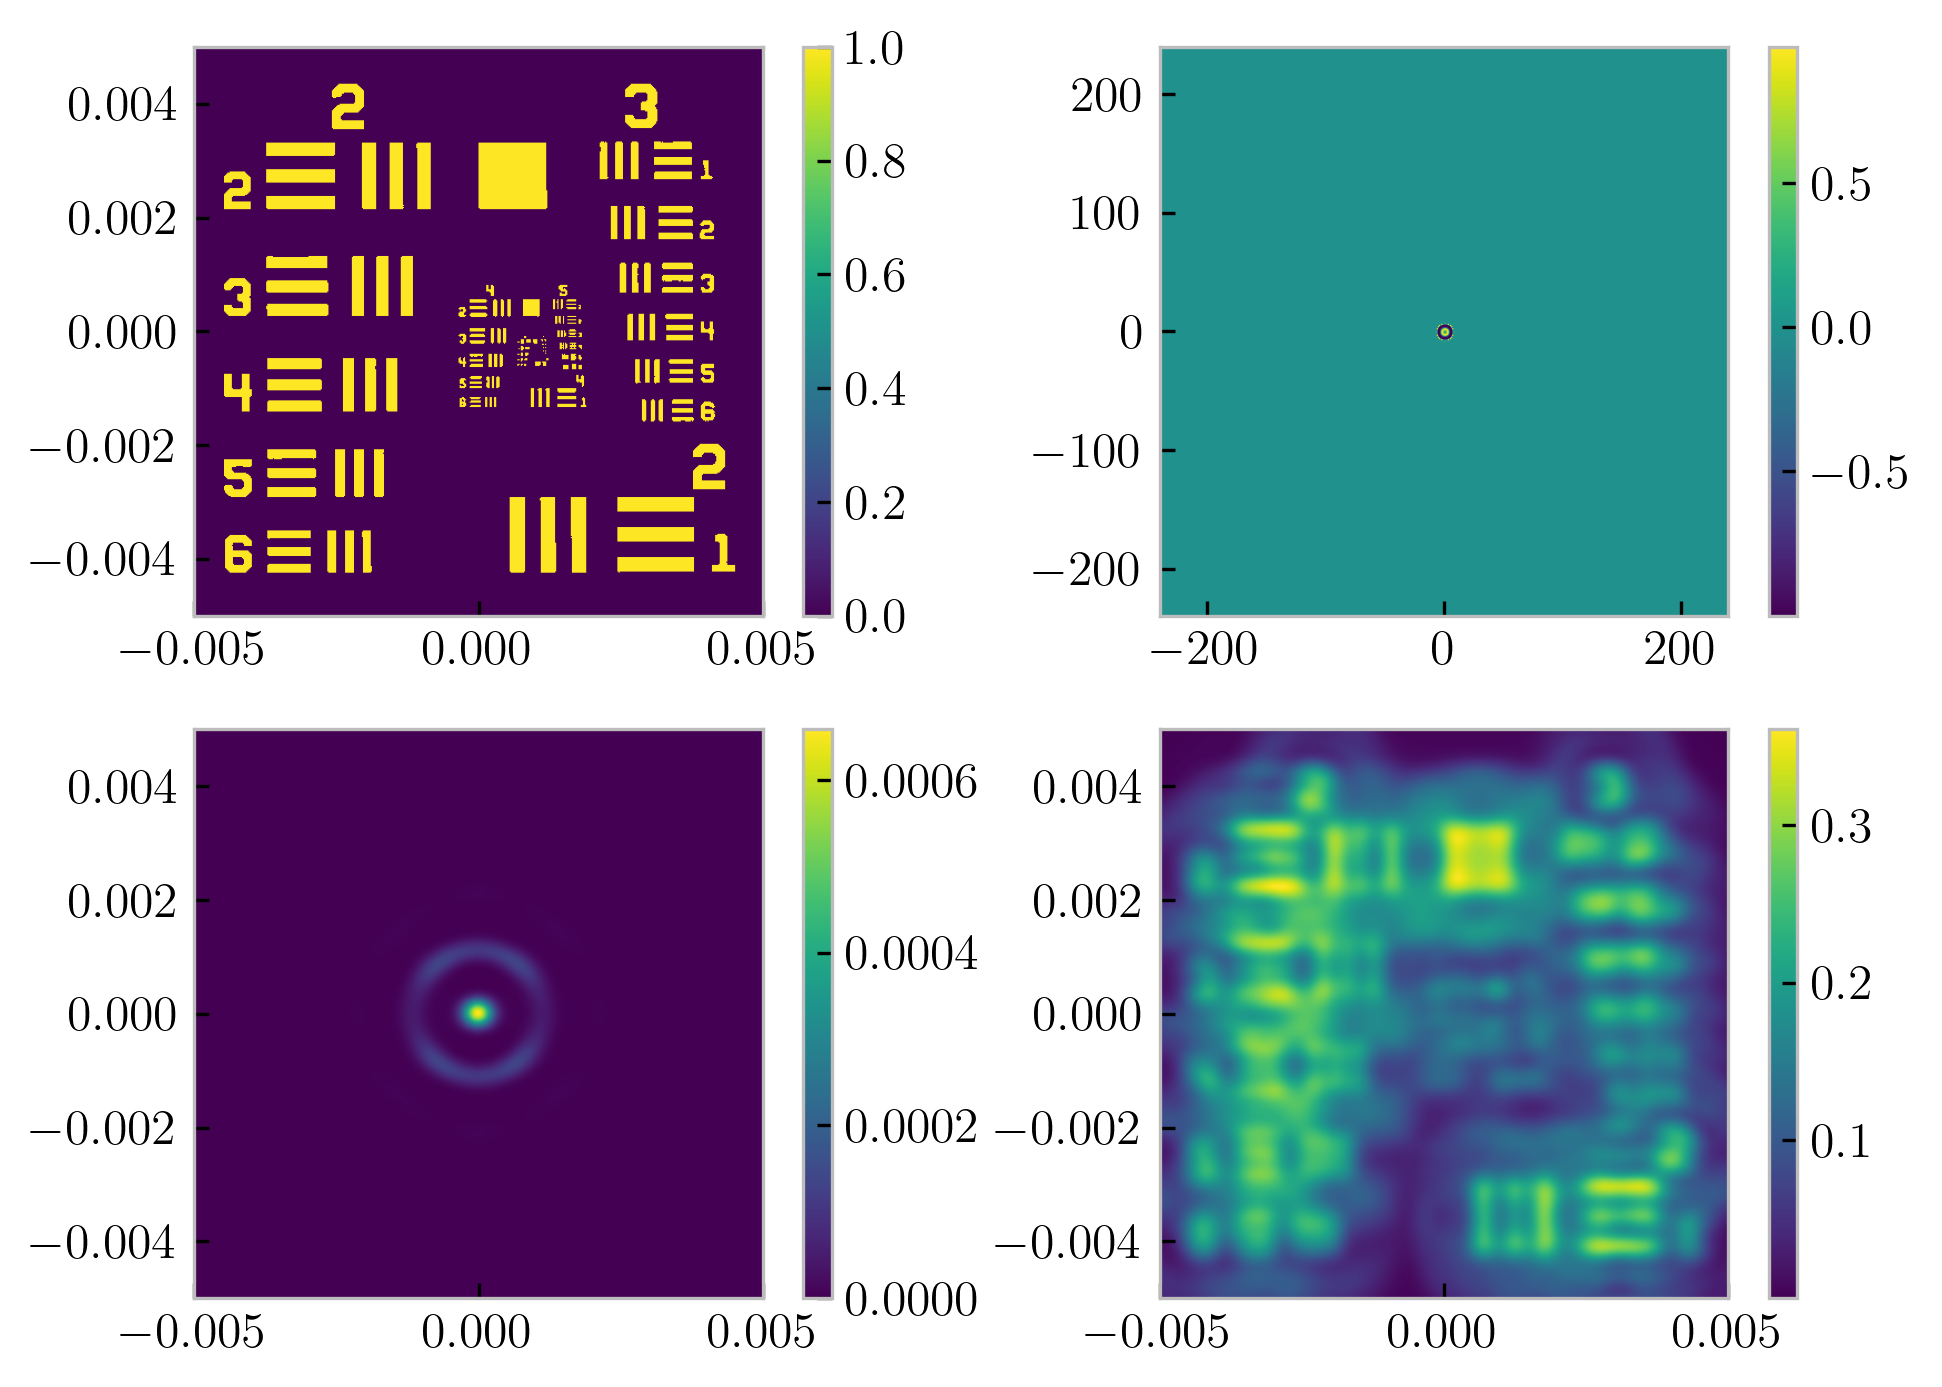

In [379]:
SNR = 1000

H = forward_H(microscope, true_aberration)
PSF = forward_PSF(microscope, grid, true_aberration)
#plot_intensity(x, y, PSF, normalize = False)
d = forward_image(microscope,grid, f, true_aberration)
d = add_gaussian_noise(d, SNR, rng)
#plot_intensity(x, y, d, normalize = False)

fig, axs = plt.subplots(2, 2)
axs = axs.flatten()

im0 = axs[0].imshow(f,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im1 = axs[1].imshow(np.imag(H),
                    extent=[x_bfp[0], x_bfp[-1], y_bfp[0], y_bfp[-1]],)

im2 = axs[2].imshow(PSF,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im3= axs[3].imshow(d,
                   extent=[x[0], x[-1], y[0], y[-1]],)

for ax in axs:
    ax.grid(False)
    #ax.set_xticks([])
    #ax.set_yticks([])



fig.colorbar(im0, ax = axs[0])
fig.colorbar(im1, ax = axs[1])
fig.colorbar(im2, ax = axs[2])
fig.colorbar(im3, ax = axs[3])

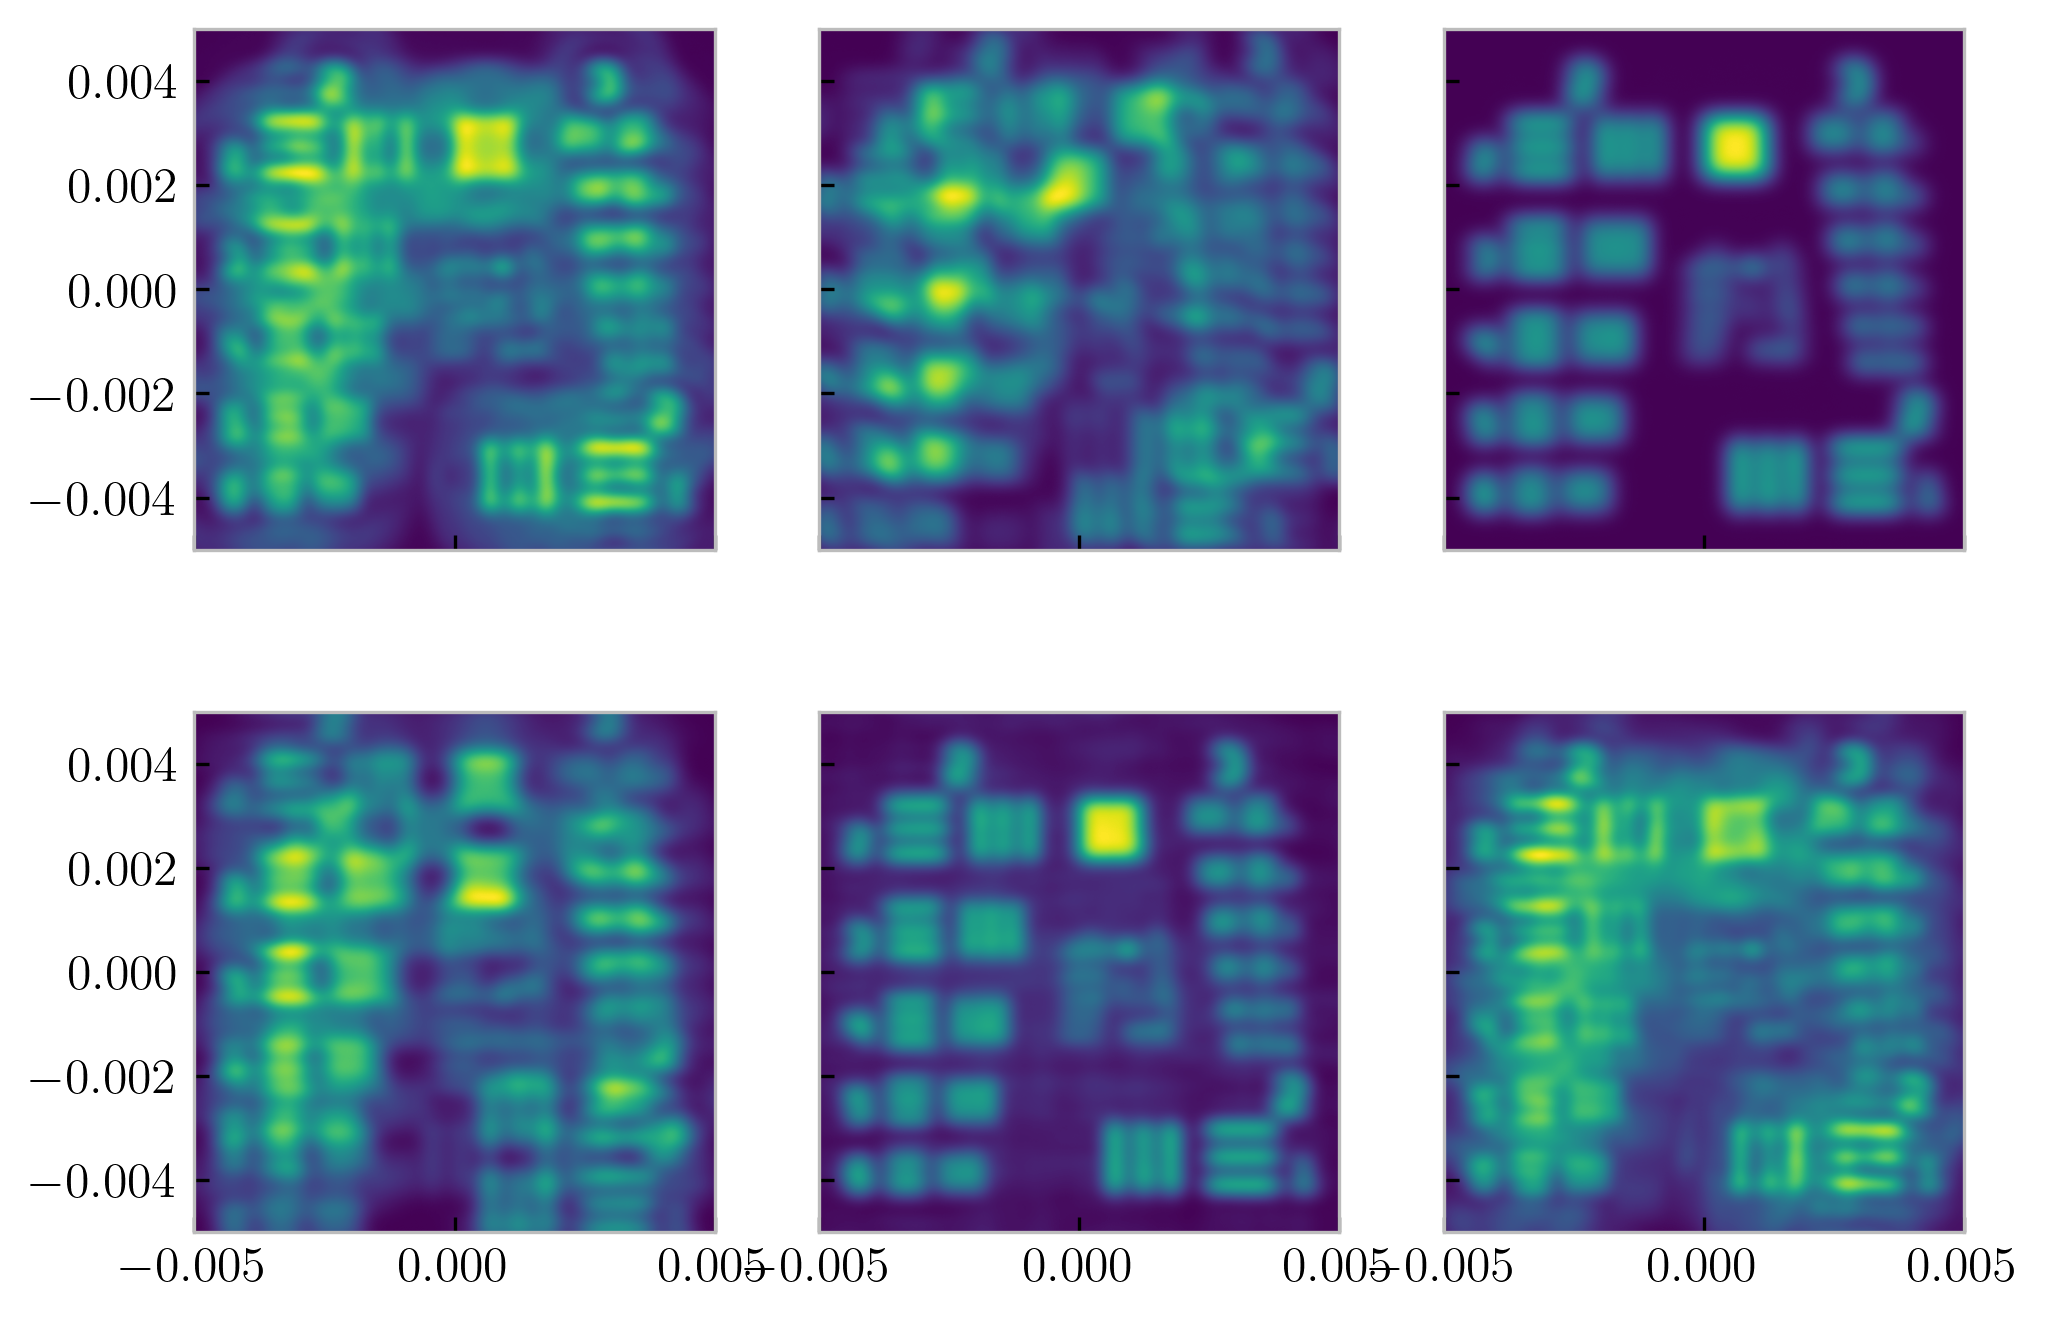

In [380]:
bias_modes = [[-2,2], [0,2], [2,2],
[0, 4], [-4,4], [4,4]]
bias_strength = 0.5
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]
d_stack = np.array([forward_image(microscope, grid, f, true_aberration + a) for a in a_stack])

d_stack = [add_gaussian_noise(d, SNR, rng) for d in d_stack]

a = 2
b = 3
fig, axs = plt.subplots(a, b, sharex= True, sharey = True)
axs = axs.flatten()
for i in range(a * b):
    axs[i].imshow(d_stack[i],extent=[x[0], x[-1], y[0], y[-1]])
    axs[i].grid(False)


In [381]:
def objective(microscope, grid, D_stack, a_proposed, a_stack, gamma):
    s_stack = [forward_PSF(microscope, grid, a_proposed + a) for a in a_stack]
    S_stack = np.stack([fft2(s, workers = -1) for s in s_stack], axis=0)
    first_term = np.sum(np.abs(D_stack)**2)

    numerator = np.abs(np.sum(np.conj(S_stack) * D_stack, axis=0))**2
    denominator = gamma + np.sum(np.abs(S_stack)**2, axis=0)

    return np.real(first_term - np.sum(numerator / denominator))

#grid = grid along which the images were taken
#d_stack = list of phase diverse images
#a_stack = list of aberrations applied along each phase diverse image
#aberration_guesss = guess for the inherent sample aberration
#gamma = regularization parameters
def estimate_object(microscope,
                    grid,
                    d_stack,
                    a_stack,
                    a_proposed,
                    gamma):
    N = len(d_stack)
    s_stack = [forward_PSF(microscope, grid, a_proposed + a) for a in a_stack]
    S_stack = np.stack([fft2(s, workers = -1) for s in s_stack], axis=0)
    D_stack = np.stack([fft2(d, workers = -1) for d in d_stack], axis=0)
    #compute the estimator
    numerator = np.sum([np.conj(S_stack[j]) * D_stack[j] for j in range(N)], axis = 0)
    denominator = gamma + np.sum([np.abs(S_stack[j])**2 for j in range(N)], axis = 0 )
    F = numerator/denominator 
    f = ifftshift(ifft2(F))
    return np.real(f), F


In [382]:
from scipy.optimize import minimize
from scipy.optimize import Bounds
import time

In [383]:
def optimize(microscope, grid, d_stack, a_stack, modes_corrected, gamma):
    D_stack = np.fft.fft2(np.asarray(d_stack), axes=(-2, -1))
    iter_counter = {"n": 0}

    def single_arg_objective(c_guess):
        return objective(
            microscope,
            grid,
            D_stack,
            Aberration(modes_corrected, c_guess),
            a_stack,
            gamma,
        )

    def callback(c_guess):
        iter_counter["n"] += 1
        J = single_arg_objective(c_guess)
        print(f"iter {iter_counter['n']:4d}: J = {J:.6e}")
        print(f"    c = {c_guess}")

    options = {
        "disp": True,
        "return_all": True,
        "maxiter": 1000,
        "xtol": 1e-8,
        "ftol": 1e-12,
    }

    for c in [0.0, 0.25, 0.5, 0.75, 1.0]:
        t = time.time()
        single_arg_objective([c])
        s = time.time()
        print(s-t)

    return minimize(
            single_arg_objective,
            x0=np.zeros(len(modes_corrected)),
            method="Powell",
            bounds=Bounds(-1, 1),
            options={
                "disp": True,
                "maxiter": 100,
                "ftol": 1e-12,
                "gtol": 1e-8,
            }, callback = callback
)

In [384]:
modes_corrected = true_aberration.modes
result = optimize(microscope, grid, d_stack, a_stack, modes_corrected, 1e-6)

0.59055495262146
0.5899477005004883
0.5425639152526855
0.5491352081298828
0.5583188533782959


/var/folders/v9/czyc2p85057bkq0_b7k6tp2r0000gn/T/ipykernel_83712/622316497.py:35: OptimizeWarning: Unknown solver options: gtol
  return minimize(


KeyboardInterrupt: 